# Basic Sequence-to-Sequence Translation

In [1]:
# Check that TensorFlow detects the T4 GPU
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Load the English-French datasets in Colab
import pandas as pd

train_df = pd.read_csv("en_fr_train.csv")
val_df = pd.read_csv("en_fr_val.csv")
test_df = pd.read_csv("en_fr_test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (232825, 2)
Validation: (890, 2)
Test: (8597, 2)


## Tokenization

In [3]:
#  Create a simple word-level tokenizer
import re
#
#  def tokenize(text):
#      text = str(text).lower()
#      return re.findall(r"\w+|[^\w\s]", text)
#
#  sample = train_df.loc[0, "en"]
#  print("Original:")
#  print(sample)
#  print("\nTokens:")
#  print(tokenize(sample))


# Improve tokenization by preserving contractions
def tokenize(text):
    text = str(text).lower()
    return re.findall(r"[a-z]+(?:'[a-z]+)?|[^\w\s]", text)

sample = train_df.loc[0, "en"]

print("Original:")
print(sample)

print("\nTokens:")
print(tokenize(sample))

Original:
Thank you so much, Chris. And it's truly a great honor to have the opportunity to come to this stage twice; I'm extremely grateful.

Tokens:
['thank', 'you', 'so', 'much', ',', 'chris', '.', 'and', "it's", 'truly', 'a', 'great', 'honor', 'to', 'have', 'the', 'opportunity', 'to', 'come', 'to', 'this', 'stage', 'twice', ';', "i'm", 'extremely', 'grateful', '.']


## Building vocabularies.

In [4]:
# Build English and French vocabularies
from collections import Counter

SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

eng_counter = Counter()
fra_counter = Counter()

for text in train_df["en"]:
    eng_counter.update(tokenize(text))

for text in train_df["fr"]:
    fra_counter.update(tokenize(text))

print("English unique tokens:", len(eng_counter))
print("French unique tokens:", len(fra_counter))

print("\nMost common English tokens:")
print(eng_counter.most_common(10))

print("\nMost common French tokens:")
print(fra_counter.most_common(10))

English unique tokens: 54028
French unique tokens: 67045

Most common English tokens:
[(',', 285556), ('.', 239036), ('the', 193586), ('and', 138376), ('to', 116017), ('of', 106723), ('a', 97910), ('that', 78221), ('in', 72826), ('-', 65552)]

Most common French tokens:
[(',', 272686), ('.', 242981), ('de', 172626), ('et', 116693), ('la', 95898), ('le', 81428), ('les', 79231), ('que', 78571), ('-', 67907), ('des', 59848)]


- frequency = how many times that token appears across the entire training corpus.
- Create vocabularies with a minimum frequency threshold
- min_freq=2 does NOT mean we remove those words from the dataset. We simply don't give them their own vocabulary ID; when encoding them, they'll become 'UNK'.

## Creating The Vocabularies

In [5]:
# frequency = how many times that token appears across the entire training corpus.
# Create vocabularies with a minimum frequency threshold
MIN_FREQ = 2

eng_vocab = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}
fra_vocab = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}

for token, count in eng_counter.items():
    if count >= MIN_FREQ:
        eng_vocab[token] = len(eng_vocab)

for token, count in fra_counter.items():
    if count >= MIN_FREQ:
        fra_vocab[token] = len(fra_vocab)

print("English vocabulary size:", len(eng_vocab))
print("French vocabulary size:", len(fra_vocab))

print("\nSpecial tokens:")
print({token: eng_vocab[token] for token in SPECIAL_TOKENS})

English vocabulary size: 35309
French vocabulary size: 41836

Special tokens:
{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}


## Creating a function to convert a sentence into vocabulary ID'S using, the tokenize() function and vocabiliery that we build above

In [6]:
# Convert a sentence into vocabulary IDs
def encode_sentence(text, vocab):
    tokens = tokenize(text)

    ids = [vocab["<SOS>"]]

    for token in tokens:
        ids.append(vocab.get(token, vocab["<UNK>"])) # If the token exists in the vocabulary → give its ID ,Otherwise → give <UNK>

    ids.append(vocab["<EOS>"])

    return ids


sample_en = train_df.loc[0, "en"]
sample_fr = train_df.loc[0, "fr"]

print("English:")
print(sample_en)
print(encode_sentence(sample_en, eng_vocab))

print("\nFrench:")
print(sample_fr)
print(encode_sentence(sample_fr, fra_vocab))

English:
Thank you so much, Chris. And it's truly a great honor to have the opportunity to come to this stage twice; I'm extremely grateful.
[1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 17, 21, 17, 22, 23, 24, 25, 26, 27, 28, 10, 2]

French:
Merci beaucoup, Chris. C'est vraiment un honneur de pouvoir venir sur cette scène une deuxième fois. Je suis très reconnaissant.
[1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 8, 24, 25, 26, 27, 28, 8, 2]


In [7]:
# Encode the training sentences for TensorFlow

import tensorflow as tf

def encode_dataframe(dataframe, eng_vocab, fra_vocab):
    english_sequences = []
    french_sequences = []

    for _, row in dataframe.iterrows():
        english_sequences.append(
            encode_sentence(row["en"], eng_vocab)
        )
        french_sequences.append(
            encode_sentence(row["fr"], fra_vocab)
        )

    return english_sequences, french_sequences


train_en, train_fr = encode_dataframe(train_df, eng_vocab, fra_vocab)

print("Number of English sequences:", len(train_en))
print("Number of French sequences:", len(train_fr))

print("\nFirst English sequence:")
print(train_en[0])

print("\nFirst French sequence:")
print(train_fr[0])
import tensorflow as tf

def encode_dataframe(dataframe, eng_vocab, fra_vocab):
    english_sequences = []
    french_sequences = []

    for _, row in dataframe.iterrows():
        english_sequences.append(
            encode_sentence(row["en"], eng_vocab)
        )
        french_sequences.append(
            encode_sentence(row["fr"], fra_vocab)
        )

    return english_sequences, french_sequences


train_en, train_fr = encode_dataframe(train_df, eng_vocab, fra_vocab)

print("Number of English sequences:", len(train_en))
print("Number of French sequences:", len(train_fr))

print("\nFirst English sequence:")
print(train_en[0])

print("\nFirst French sequence:")
print(train_fr[0])

Number of English sequences: 232825
Number of French sequences: 232825

First English sequence:
[1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 17, 21, 17, 22, 23, 24, 25, 26, 27, 28, 10, 2]

First French sequence:
[1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 8, 24, 25, 26, 27, 28, 8, 2]
Number of English sequences: 232825
Number of French sequences: 232825

First English sequence:
[1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 17, 21, 17, 22, 23, 24, 25, 26, 27, 28, 10, 2]

First French sequence:
[1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 8, 24, 25, 26, 27, 28, 8, 2]


# Embedding
- Embedding layer converts each ID into a learnable vector
- We will need two embedding layers - English and French

In [8]:
# Create English and French embedding layers
import tensorflow as tf

EMBEDDING_DIM = 256

eng_embedding = tf.keras.layers.Embedding(
    input_dim=len(eng_vocab),
    output_dim=EMBEDDING_DIM,
    mask_zero=True                    # id=0 is PAD so dont treat it as real info
)

fra_embedding = tf.keras.layers.Embedding(
    input_dim=len(fra_vocab),
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)

print("English embedding:", eng_embedding)
print("French embedding:", fra_embedding)

English embedding: <Embedding name=embedding, built=False>
French embedding: <Embedding name=embedding_1, built=False>


## USING ONE ENGLISH SEQUENCE TO TEST:-
### 1) EMBEDDING
### 2) ENCODER LSTM
### 3) DECODER LSTM
### 4) OUTPUT LAYER

In [9]:
# TESTING EMBEDDING ON AN ENGLISH SEQUENCE
# See how token IDs become embedding vectors of 254D
sample_ids = tf.constant([train_en[0]])

embedded = eng_embedding(sample_ids)

print("Input shape:", sample_ids.shape)
print("Embedding shape:", embedded.shape)
print("First token ID:", sample_ids[0, 0])
print("First token embedding:", embedded[0, 0])

Input shape: (1, 30)
Embedding shape: (1, 30, 256)
First token ID: tf.Tensor(1, shape=(), dtype=int32)
First token embedding: tf.Tensor(
[-0.03313148  0.04105897  0.03562487 -0.0098008   0.03372062 -0.01008028
 -0.04129622 -0.00358047  0.01217983 -0.03737297  0.04704067 -0.02466568
 -0.0493745   0.04871922 -0.00521296  0.0045236   0.04998246 -0.02829766
  0.0039242   0.02974545  0.01473499 -0.04043347 -0.01102724 -0.0261972
  0.00698616 -0.03048819 -0.01658648  0.04256009  0.04822688  0.02663987
 -0.00152961  0.01690879 -0.03654066 -0.02963623 -0.04990928 -0.04476657
  0.04214016 -0.00813865 -0.01674123 -0.0223358  -0.00890629 -0.01741345
 -0.0257134  -0.04939495  0.03720054  0.01076307  0.04020072 -0.0164361
  0.02939529 -0.01778847 -0.03042446 -0.03640922 -0.01072888 -0.0242946
  0.01247704 -0.01285147  0.00841348 -0.04135312 -0.04120417 -0.00460929
  0.01764089  0.03131696  0.01850447  0.02490607 -0.04991026 -0.02066839
 -0.00844895 -0.00383049  0.00801487 -0.0274616  -0.00865419  0

- These 256 numbers currently look random because the embedding hasn't been trained yet. During training, backpropagation will adjust them so that useful linguistic relationships are learned.



# ENCODER LSTM

In [10]:
# Create the LSTM encoder
ENCODER_UNITS = 512

encoder_lstm = tf.keras.layers.LSTM(
    ENCODER_UNITS,
    return_sequences=True,
    return_state=True
)

encoder_outputs, encoder_h, encoder_c = encoder_lstm(embedded)

print("Encoder outputs:", encoder_outputs.shape)
print("Final hidden state:", encoder_h.shape)
print("Final cell state:", encoder_c.shape)

Encoder outputs: (1, 30, 512)
Final hidden state: (1, 512)
Final cell state: (1, 512)




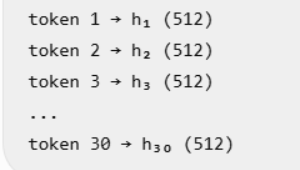
- We dont use all these Encoder Outputs yet as there is no Attention blocks
- We will use final outputs:- 1) encoder_h(1,512) , 2) encoder_c(1,512)

# DECODER LSTM

- unlike the encoder, the decoder needs to produce a probability distribution over all 41,836 French vocabulary tokens at every timestep.

- During training, we'll use **teacher forcing**, so instead of feeding its own previous prediction, we give it the actual previous French token.

In [11]:
# Create the LSTM decoder
decoder_lstm = tf.keras.layers.LSTM(
    ENCODER_UNITS,
    return_sequences=True,
    return_state=True
)

print(decoder_lstm)

<LSTM name=lstm_1, built=False>


In [12]:
# Pass the French sequence through the decoder
decoder_input = tf.constant([train_fr[0]])

decoder_embedded = fra_embedding(decoder_input)

decoder_outputs, decoder_h, decoder_c = decoder_lstm(
    decoder_embedded,
    initial_state=[encoder_h, encoder_c]
)

print("Decoder input:", decoder_input.shape)
print("Decoder embedding:", decoder_embedded.shape)
print("Decoder outputs:", decoder_outputs.shape)
print("Decoder final hidden:", decoder_h.shape)
print("Decoder final cell:", decoder_c.shape)

Decoder input: (1, 29)
Decoder embedding: (1, 29, 256)
Decoder outputs: (1, 29, 512)
Decoder final hidden: (1, 512)
Decoder final cell: (1, 512)


- 1 sentence
- 29 French input tokens
- 512 features from the LSTM

These 512 features are not word probabilities yet

- Why 29 instead of 30? Because we'll eventually give the decoder everything except 'EOS', and ask it to predict everything shifted by one position.


- At one timestep, the highest probability becomes the predicted token


In [13]:
# Create the decoder output layer
decoder_dense = tf.keras.layers.Dense(
    len(fra_vocab),
    activation="softmax"
)

predictions = decoder_dense(decoder_outputs)

print("Predictions shape:", predictions.shape)

Predictions shape: (1, 29, 41836)


- Our french vocabulary has 41836 tokens hence dense layer+softmax transform 512 features into 41886 number of probabilities

- **At each of the 29 timesteps, we now have a probability for every French token.**

### Lets start training, but first we need to do padding to handle variable sentence lengths

In [14]:
# Create padded TensorFlow datasets for training
BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_generator(
    lambda: zip(train_en, train_fr),
    output_signature=(
        tf.TensorSpec(shape=(None,), dtype=tf.int32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)

train_dataset = train_dataset.shuffle(10000)

train_dataset = train_dataset.padded_batch(
    BATCH_SIZE,
    padded_shapes=([None], [None]),
    padding_values=(0, 0)
)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("Dataset created.")

Dataset created.


## Create a trainable Seq2Seq model


- the same model weights are reused for every batch.

In [15]:
# Build the basic LSTM Seq2Seq model  , WE WILL BE REPLACING THIS LATER
class Seq2Seq(tf.keras.Model):
    def __init__(self, eng_vocab_size, fra_vocab_size, embedding_dim, units):
        super().__init__()

        self.eng_embedding = tf.keras.layers.Embedding(
            eng_vocab_size,
            embedding_dim,
            mask_zero=True
        )

        self.encoder_lstm = tf.keras.layers.LSTM(
            units,
            return_state=True
        )

        self.fra_embedding = tf.keras.layers.Embedding(
            fra_vocab_size,
            embedding_dim,
            mask_zero=True
        )

        self.decoder_lstm = tf.keras.layers.LSTM(
            units,
            return_sequences=True,
            return_state=True
        )

        self.decoder_dense = tf.keras.layers.Dense(
            fra_vocab_size,
            activation="softmax"
        )

    def call(self, encoder_input, decoder_input):
        # Encode English sentence
        encoder_embedded = self.eng_embedding(encoder_input)

        _, encoder_h, encoder_c = self.encoder_lstm(
            encoder_embedded
        )

        # Decode French sentence using teacher forcing
        decoder_embedded = self.fra_embedding(decoder_input)

        decoder_outputs, _, _ = self.decoder_lstm(
            decoder_embedded,
            initial_state=[encoder_h, encoder_c]
        )

        # Convert decoder outputs into token probabilities
        predictions = self.decoder_dense(decoder_outputs)

        return predictions

In [16]:
# Create the Seq2Seq model
model = Seq2Seq(
    eng_vocab_size=len(eng_vocab),
    fra_vocab_size=len(fra_vocab),
    embedding_dim=256,
    units=512
)

print("Seq2Seq model created.")

Seq2Seq model created.


### Before throwing 232K sentences , lets take one batch from tf.data.Dataset from and do training


In [17]:
# Inspect one training batch
for english_batch, french_batch in train_dataset.take(1):
    print("English batch shape:", english_batch.shape)
    print("French batch shape:", french_batch.shape)

English batch shape: (64, 78)
French batch shape: (64, 100)


- 64 = number of sentence pairs in the batch
- English sentences were padded to 64 tokens
- French sentences were padded to 68 tokens

Lets do batch size 8 rather than 64 to prevent my potato laptop from blasting and redo for one example

In [18]:
# Recreate the dataset with a smaller batch size
BATCH_SIZE = 8

train_dataset = tf.data.Dataset.from_generator(
    lambda: zip(train_en, train_fr),
    output_signature=(
        tf.TensorSpec(shape=(None,), dtype=tf.int32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)

train_dataset = train_dataset.shuffle(10000)

train_dataset = train_dataset.padded_batch(
    BATCH_SIZE,
    padded_shapes=([None], [None]),
    padding_values=(0, 0)
)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("Batch size:", BATCH_SIZE)

Batch size: 8


In [19]:
# Define the masked cross-entropy loss
# How far was the model's predicted probability distribution from the correct French token?
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction="none"
)

def loss_function(real, pred):
    loss = loss_object(real, pred)

    # Ignore <PAD> tokens
    mask = tf.cast(real != 0, loss.dtype)
    loss *= mask

    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

In [20]:
# Perform one training step
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

for english_batch, french_batch in train_dataset.take(1):

    # Remove <EOS> from decoder input
    decoder_input = french_batch[:, :-1]

    # Remove <SOS> from target
    target = french_batch[:, 1:]

    with tf.GradientTape() as tape:

        # Forward pass
        predictions = model(
            english_batch,
            decoder_input
        )

        # Calculate loss
        loss = loss_function(
            target,
            predictions
        )

    # Calculate gradients
    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    # Update model weights
    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    print("Loss:", float(loss))

Loss: 10.641526222229004


In [21]:
# Create a compiled training step with reduced retracing
@tf.function(reduce_retracing=True)
def train_step(english_batch, french_batch):

    decoder_input = french_batch[:, :-1]
    target = french_batch[:, 1:]

    with tf.GradientTape() as tape:

        predictions = model(
            english_batch,
            decoder_input
        )

        loss = loss_function(
            target,
            predictions
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return loss

In [22]:
# Test the compiled training step
import time

start_time = time.time()

for batch_number, (english_batch, french_batch) in enumerate(
    train_dataset.take(100), start=1
):

    loss = train_step(
        english_batch,
        french_batch
    )

    if batch_number % 20 == 0:
        print(
            f"Batch {batch_number}/100 | "
            f"Loss: {float(loss):.4f}"
        )

elapsed = time.time() - start_time

print(f"\nTime for 100 batches: {elapsed / 60:.2f} minutes")

Batch 20/100 | Loss: 7.1069
Batch 40/100 | Loss: 7.4407
Batch 60/100 | Loss: 6.8296
Batch 80/100 | Loss: 6.6803
Batch 100/100 | Loss: 6.7877

Time for 100 batches: 0.18 minutes


- Finding how much time would 100 batches take

- We found out that at Embeddings =256, LSTM = 512, batch = 8, the computation would take 13 hours/epoch.

- Hence we will decrease Embedding: 256 → 128 ,LSTM: 512 → 256, Batch:       8 → 16

## Build a lighter Seq2Seq model

In [23]:
# Build a lighter Seq2Seq model
class Seq2Seq(tf.keras.Model):
    def __init__(self, eng_vocab_size, fra_vocab_size, embedding_dim, units):
        super().__init__()

        self.eng_embedding = tf.keras.layers.Embedding(
            eng_vocab_size,
            embedding_dim,
            mask_zero=True
        )

        self.encoder_lstm = tf.keras.layers.LSTM(
            units,
            return_state=True
        )

        self.fra_embedding = tf.keras.layers.Embedding(
            fra_vocab_size,
            embedding_dim,
            mask_zero=True
        )

        self.decoder_lstm = tf.keras.layers.LSTM(
            units,
            return_sequences=True,
            return_state=True
        )

        self.decoder_dense = tf.keras.layers.Dense(
            fra_vocab_size,
            activation="softmax"
        )

    def call(self, encoder_input, decoder_input):

        encoder_embedded = self.eng_embedding(encoder_input)

        _, encoder_h, encoder_c = self.encoder_lstm(
            encoder_embedded
        )

        decoder_embedded = self.fra_embedding(decoder_input)

        decoder_outputs, _, _ = self.decoder_lstm(
            decoder_embedded,
            initial_state=[encoder_h, encoder_c]
        )

        predictions = self.decoder_dense(decoder_outputs)

        return predictions


model = Seq2Seq(
    eng_vocab_size=len(eng_vocab),
    fra_vocab_size=len(fra_vocab),
    embedding_dim=128,
    units=256
)

print("Lighter Seq2Seq model created.")

Lighter Seq2Seq model created.


## Recreate the dataset with batch 16

In [24]:
# Recreate the dataset with a larger batch size
BATCH_SIZE = 16

train_dataset = tf.data.Dataset.from_generator(
    lambda: zip(train_en, train_fr),
    output_signature=(
        tf.TensorSpec(shape=(None,), dtype=tf.int32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
)

train_dataset = train_dataset.shuffle(10000)

train_dataset = train_dataset.padded_batch(
    BATCH_SIZE,
    padded_shapes=([None], [None]),
    padding_values=(0, 0)
)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("Batch size:", BATCH_SIZE)

Batch size: 16


In [25]:
# Create the optimizer for the new model
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Optimizer ready.")

Optimizer ready.


Now lets do benchmark test on lighter model

In [26]:
# Recreate the compiled training step for the new model
@tf.function(reduce_retracing=True)
def train_step(english_batch, french_batch):

    decoder_input = french_batch[:, :-1]
    target = french_batch[:, 1:]

    with tf.GradientTape() as tape:

        predictions = model(
            english_batch,
            decoder_input
        )

        loss = loss_function(
            target,
            predictions
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return loss

In [27]:
# Benchmark the lighter model
import time

start_time = time.time()

for batch_number, (english_batch, french_batch) in enumerate(
    train_dataset.take(100), start=1
):

    loss = train_step(
        english_batch,
        french_batch
    )

    if batch_number % 20 == 0:
        print(
            f"Batch {batch_number}/100 | "
            f"Loss: {float(loss):.4f}"
        )

elapsed = time.time() - start_time

print(f"\nTime for 100 batches: {elapsed / 60:.2f} minutes")

Batch 20/100 | Loss: 7.7031
Batch 40/100 | Loss: 6.8797
Batch 60/100 | Loss: 7.0488
Batch 80/100 | Loss: 6.6956
Batch 100/100 | Loss: 6.8712

Time for 100 batches: 0.19 minutes


In [28]:
# Encode validation and test sentences
val_en, val_fr = encode_dataframe(val_df, eng_vocab, fra_vocab)
test_en, test_fr = encode_dataframe(test_df, eng_vocab, fra_vocab)

print("Validation sequences:", len(val_en))
print("Test sequences:", len(test_en))

Validation sequences: 890
Test sequences: 8597


In [29]:
# Train the lighter Seq2Seq model for one epoch
import time

start_time = time.time()

total_loss = 0
batch_count = 0

for english_batch, french_batch in train_dataset:
    loss = train_step(english_batch, french_batch)

    total_loss += float(loss)
    batch_count += 1

    if batch_count % 500 == 0:
        print(
            f"Batch {batch_count} | "
            f"Average loss: {total_loss / batch_count:.4f}"
        )

epoch_loss = total_loss / batch_count

elapsed = time.time() - start_time

print(f"\nEpoch loss: {epoch_loss:.4f}")
print(f"Time: {elapsed / 60:.2f} minutes")

Batch 500 | Average loss: 6.1011
Batch 1000 | Average loss: 5.8783
Batch 1500 | Average loss: 5.7128
Batch 2000 | Average loss: 5.5701
Batch 2500 | Average loss: 5.4491
Batch 3000 | Average loss: 5.3420
Batch 3500 | Average loss: 5.2542
Batch 4000 | Average loss: 5.1731
Batch 4500 | Average loss: 5.1004
Batch 5000 | Average loss: 5.0347
Batch 5500 | Average loss: 4.9746
Batch 6000 | Average loss: 4.9156
Batch 6500 | Average loss: 4.8610
Batch 7000 | Average loss: 4.8087
Batch 7500 | Average loss: 4.7611
Batch 8000 | Average loss: 4.7163
Batch 8500 | Average loss: 4.6768
Batch 9000 | Average loss: 4.6427
Batch 9500 | Average loss: 4.6135
Batch 10000 | Average loss: 4.5850
Batch 10500 | Average loss: 4.5588
Batch 11000 | Average loss: 4.5342
Batch 11500 | Average loss: 4.5117
Batch 12000 | Average loss: 4.4912
Batch 12500 | Average loss: 4.4715
Batch 13000 | Average loss: 4.4520
Batch 13500 | Average loss: 4.4326
Batch 14000 | Average loss: 4.4140
Batch 14500 | Average loss: 4.3963

Epoc

The model is definitely learning. The decreasing loss means the encoder-decoder is getting better at predicting the next French token.

**Inference Function**

In [30]:
# Convert an English sentence into model input IDs
def encode_input_sentence(sentence):
    return encode_sentence(sentence, eng_vocab)

In [31]:
# Generate a French translation from an English sentence
def translate(sentence, max_length=50):
    english_ids = encode_input_sentence(sentence)
    encoder_input = tf.constant([english_ids])

    # Encode the English sentence
    encoder_embedded = model.eng_embedding(encoder_input)
    _, encoder_h, encoder_c = model.encoder_lstm(encoder_embedded)

    # Start decoding with <SOS>
    current_token = fra_vocab["<SOS>"]
    generated_tokens = []

    for _ in range(max_length):
        decoder_input = tf.constant([[current_token]])

        decoder_embedded = model.fra_embedding(decoder_input)

        decoder_output, encoder_h, encoder_c = model.decoder_lstm(
            decoder_embedded,
            initial_state=[encoder_h, encoder_c]
        )

        prediction = model.decoder_dense(decoder_output)

        next_token = int(tf.argmax(prediction[0, 0]).numpy())

        if next_token == fra_vocab["<EOS>"]:
            break

        generated_tokens.append(next_token)
        current_token = next_token

    return generated_tokens

In [32]:
# Test the trained model on one English sentence
test_sentence = test_df.iloc[0]["en"]

generated_ids = translate(test_sentence)

print("English:", test_sentence)
print("Generated French IDs:", generated_ids)

English: Several years ago here at TED, Peter Skillman  introduced a design challenge  called the marshmallow challenge.
Generated French IDs: [127, 211, 89, 73, 6, 127, 211, 89, 11, 859, 13, 122, 12034, 6, 172, 89, 30, 94, 3987, 178, 92, 100, 3878, 6, 127, 211, 89, 11, 94, 17860, 13, 100, 111, 4463, 8]


In [33]:
# Create a mapping from French token IDs back to words
fra_id_to_token = {idx: token for token, idx in fra_vocab.items()}

generated_tokens = [
    fra_id_to_token.get(token_id, "<UNK>")
    for token_id in generated_ids
]

print("Generated French:", generated_tokens)
print("Generated sentence:", " ".join(generated_tokens))

Generated French: ['il', 'y', 'a', 'ans', ',', 'il', 'y', 'a', 'un', 'projet', 'de', 'r', 'demption', ',', 'qui', 'a', 't', 'd', 'plac', 'e', 'dans', 'la', 'rue', ',', 'il', 'y', 'a', 'un', 'd', 'pistage', 'de', 'la', 'm', 'decine', '.']
Generated sentence: il y a ans , il y a un projet de r demption , qui a t d plac e dans la rue , il y a un d pistage de la m decine .


In [34]:
# Evaluate BLEU on 100 test sentences
from nltk.translate.bleu_score import corpus_bleu

references = []
hypotheses = []

for i in range(100):
    english_sentence = test_df.iloc[i]["en"]
    french_sentence = test_df.iloc[i]["fr"]

    generated_ids = translate(english_sentence)

    generated_tokens = [
        fra_id_to_token.get(token_id, "<UNK>")
        for token_id in generated_ids
    ]

    reference_tokens = tokenize(french_sentence)

    references.append([reference_tokens])
    hypotheses.append(generated_tokens)

bleu_score = corpus_bleu(references, hypotheses)

print("BLEU score on 100 test sentences:", bleu_score)

BLEU score on 100 test sentences: 0.04626888818488365


let's inspect a few actual translations alongside their references. This gives us concrete failure examples for the report.

In [35]:
# Inspect sample translations and reference translations
for i in range(5):
    english_sentence = test_df.iloc[i]["en"]
    reference_sentence = test_df.iloc[i]["fr"]

    generated_ids = translate(english_sentence)

    generated_tokens = [
        fra_id_to_token.get(token_id, "<UNK>")
        for token_id in generated_ids
    ]

    print(f"\nExample {i + 1}")
    print("English:   ", english_sentence)
    print("Reference: ", reference_sentence)
    print("Generated: ", " ".join(generated_tokens))


Example 1
English:    Several years ago here at TED, Peter Skillman  introduced a design challenge  called the marshmallow challenge.
Reference:  Il y a plusieurs années, ici à Ted, Peter Skillman a présenté une épreuve de conception appelée l'épreuve du marshmallow.
Generated:  il y a ans , il y a un projet de r demption , qui a t d plac e dans la rue , il y a un d pistage de la m decine .

Example 2
English:    And the idea's pretty simple:  Teams of four have to build the tallest free-standing structure  out of 20 sticks of spaghetti,  one yard of tape, one yard of string  and a marshmallow.
Reference:  Et l'idée est plutôt simple. Des équipes de quatre personnes doivent bâtir la plus haute structure tenant debout avec 20 spaghettis, un mètre de ruban collant, un mètre de ficelle, et un marshmallow.
Generated:  et le d veloppement de la m decine quantique , qui est l ' quivalent de la maison de la maison , un homme qui se passe dans un village , et le d pistage de la mort , la m me

# BLEU Evaluation and Failure Analysis

After training the basic LSTM Seq2Seq model for one epoch, we evaluated its translation quality using BLEU on the first 100 sentences from the held-out test set.

## BLEU Evaluation

For each test sentence, the English input was passed through the encoder. The decoder was then started with `<SOS>` and generated the French translation one token at a time. The predicted token was fed back into the decoder until `<EOS>` was generated.

The generated French translation was then compared with the reference French translation using BLEU.

### BLEU Score

```text
BLEU = 0.04626888818488365

## Translation Analysis

To understand the BLEU score better, we inspected individual translations from the test set.

### Example 1

**English:**

> Several years ago here at TED, Peter Skillman introduced a design challenge called the marshmallow challenge.

**Reference:**

> Il y a plusieurs années, ici à Ted, Peter Skillman a présenté une épreuve de conception appelée l'épreuve du marshmallow.

**Generated:**

> il y a ans , il y a un projet de r demption , qui a t d plac e dans la rue , il y a un d pistage de la m decine .

**Analysis:**

The model correctly generates some common French tokens such as `il`, `y`, and `a`, but it fails to preserve the meaning of the English sentence.

The output quickly moves from the correct opening into unrelated concepts such as `r demption`, `rue`, and `m decine`.

This demonstrates **semantic drift**, where the decoder generates plausible French word sequences without maintaining a strong connection to the original English sentence.

The sentence is also relatively long, making the problem more severe because the basic encoder-decoder must compress the entire source sentence into the encoder's final hidden and cell states.

---

### Example 2

**English:**

> And the idea's pretty simple: Teams of four have to build the tallest free-standing structure out of 20 sticks of spaghetti, one yard of tape, one yard of string and a marshmallow.

**Reference:**

> Et l'idée est plutôt simple. Des équipes de quatre personnes doivent bâtir la plus haute structure tenant debout avec 20 spaghettis, un mètre de ruban collant, un mètre de ficelle, et un marshmallow.

**Generated:**

> et le d veloppement de la m decine quantique , qui est l ' quivalent de la maison de la maison , un homme qui se passe dans un village , et le d pistage de la mort , la m me chose de la maison , et le `<UNK>`

**Analysis:**

The model fails to preserve almost all of the meaning of the original sentence.

Instead of translating concepts such as teams, spaghetti, tape, string, and marshmallow, it generates unrelated concepts such as `médecine`, `maison`, `village`, and `mort`.

The output also contains repetition:

> `de la maison de la maison`

and ends with an `<UNK>` token.

This strongly demonstrates the difficulty of the basic encoder-decoder in handling long sequences and maintaining relevant information from the source sentence.

---

### Example 3

**English:**

> The marshmallow has to be on top.

**Reference:**

> Le marshmallow doit être placé au sommet.

**Generated:**

> le fait est que a a t d j .

**Analysis:**

Even though this is a short sentence, the model fails to produce the correct translation.

The generated output contains common French words and a French-like structure such as `le fait est que`, but it does not preserve the meaning of the English sentence.

Important concepts such as `marshmallow`, `placed`, and `top` are not correctly represented.

This shows that the model's weakness is not only caused by long sentences. At the current stage of training, it has learned some general French patterns but has not learned reliable English-to-French word and phrase mappings.

---

### Example 4

**English:**

> And, though it seems really simple, it's actually pretty hard because it forces people to collaborate very quickly.

**Reference:**

> Bien que cela semble vraiment simple, c'est en fait plutôt difficile, parce que ça oblige les gens à collaborer rapidement.

**Generated:**

> et c'est tr s difficile de dire que ce sont les probl mes , car ils sont tr s diff rentes .

**Analysis:**

The model captures some information related to the original sentence. For example, it generates `et c'est tr s difficile`, which is related to the idea that the task is difficult.

However, the rest of the sentence does not correctly represent the original meaning. The concepts of people being forced to collaborate quickly are not preserved.

The output also contains fragmented words such as `tr s` and `diff rentes`.

This suggests that the model has learned some frequently occurring French patterns but struggles to maintain the complete semantic structure of the source sentence.

---

### Example 5

**English:**

> And so, I thought this was an interesting idea, and I incorporated it into a design workshop.

**Reference:**

> J'ai trouvé que c'était une idée intéressante, alors je l'ai insérée dans un atelier de conception.

**Generated:**

> et donc je suis devenu un peu de temps , et j'ai fait une id e de la vie , et c'est un peu plus .

**Analysis:**

The model produces some French structures that are related to the input, such as `et donc`, `j'ai`, and `une id e`.

However, the overall meaning is not preserved. The reference describes finding an idea interesting and incorporating it into a design workshop, while the generated translation introduces unrelated phrases such as `un peu de temps` and `de la vie`.

This demonstrates that the model can generate locally plausible French phrases but struggles to maintain the complete meaning of the source sentence.

---

## Overall Failure Analysis

The examples reveal several important weaknesses of the basic Seq2Seq model.

### 1. Context Bottleneck

The basic encoder-decoder compresses the entire English sentence into the encoder's final hidden and cell states.

For longer sentences, important information can be lost during this compression. This is particularly visible in Examples 1 and 2, where the decoder quickly loses the relationship with the source sentence.

### 2. Semantic Drift

The decoder sometimes generates French-looking text that is unrelated to the input.

For example, concepts such as `médecine`, `village`, `maison`, and `mort` appear in generated translations even though they are unrelated to the corresponding English sentences.

### 3. Repetition

The decoder sometimes falls into repetitive patterns, such as:

> `de la maison de la maison`

This indicates that the autoregressive decoder can repeatedly select high-probability tokens instead of producing the correct translation.

### 4. Unknown Tokens

The `<UNK>` token appears in Example 2.

This indicates that some words cannot be represented by the learned vocabulary, particularly less frequent words.

### 5. Word Fragmentation

Several generated outputs contain fragmented words such as:

```text
r demption
d veloppement
m decine
tr s
d j

In [38]:
# Train the Seq2Seq model for epochs 2 and 3
import time

for epoch in range(2, 4):

    start_time = time.time()

    total_loss = 0
    batch_count = 0

    for english_batch, french_batch in train_dataset:
        loss = train_step(english_batch, french_batch)

        total_loss += float(loss)
        batch_count += 1

        if batch_count % 500 == 0:
            print(
                f"Epoch {epoch} | "
                f"Batch {batch_count} | "
                f"Average loss: {total_loss / batch_count:.4f}"
            )

    epoch_loss = total_loss / batch_count
    elapsed = time.time() - start_time

    print(f"\nEpoch {epoch} loss: {epoch_loss:.4f}")
    print(f"Epoch {epoch} time: {elapsed / 60:.2f} minutes\n")

Epoch 2 | Batch 500 | Average loss: 3.8501
Epoch 2 | Batch 1000 | Average loss: 3.8238
Epoch 2 | Batch 1500 | Average loss: 3.8161
Epoch 2 | Batch 2000 | Average loss: 3.7943
Epoch 2 | Batch 2500 | Average loss: 3.7753
Epoch 2 | Batch 3000 | Average loss: 3.7607
Epoch 2 | Batch 3500 | Average loss: 3.7473
Epoch 2 | Batch 4000 | Average loss: 3.7294
Epoch 2 | Batch 4500 | Average loss: 3.7130
Epoch 2 | Batch 5000 | Average loss: 3.6962
Epoch 2 | Batch 5500 | Average loss: 3.6826
Epoch 2 | Batch 6000 | Average loss: 3.6632
Epoch 2 | Batch 6500 | Average loss: 3.6469
Epoch 2 | Batch 7000 | Average loss: 3.6289
Epoch 2 | Batch 7500 | Average loss: 3.6127
Epoch 2 | Batch 8000 | Average loss: 3.5963
Epoch 2 | Batch 8500 | Average loss: 3.5844
Epoch 2 | Batch 9000 | Average loss: 3.5752
Epoch 2 | Batch 9500 | Average loss: 3.5710
Epoch 2 | Batch 10000 | Average loss: 3.5660
Epoch 2 | Batch 10500 | Average loss: 3.5619
Epoch 2 | Batch 11000 | Average loss: 3.5576
Epoch 2 | Batch 11500 | Averag

Old BLEU for 100 batches was 0.04627 after Epoch 1, now lets find BLEU after Epoch 3

In [39]:
# Recalculate BLEU on the first 100 test sentences after Epoch 3

from nltk.translate.bleu_score import corpus_bleu
import nltk

nltk.download("punkt", quiet=True)

references = []
hypotheses = []

for i in range(100):
    # Generate translation
    generated_ids = translate(test_df.iloc[i]["en"])

    # Convert IDs to tokens
    generated_tokens = [
        fra_id_to_token[token_id]
        for token_id in generated_ids
        if token_id not in [
            fra_vocab["<PAD>"],
            fra_vocab["<SOS>"],
            fra_vocab["<EOS>"]
        ]
    ]

    # Convert reference sentence to tokens
    reference_tokens = tokenize(test_df.iloc[i]["fr"])

    references.append([reference_tokens])
    hypotheses.append(generated_tokens)

bleu_score = corpus_bleu(references, hypotheses)

print(f"BLEU after Epoch 3: {bleu_score:.6f}")

BLEU after Epoch 3: 0.067696


In [40]:
# Generate final translation examples after Epoch 3

for i in range(5):
    english = test_df.iloc[i]["en"]
    reference = test_df.iloc[i]["fr"]

    generated_ids = translate(english)

    generated = " ".join(
        fra_id_to_token[token_id]
        for token_id in generated_ids
        if token_id not in [
            fra_vocab["<PAD>"],
            fra_vocab["<SOS>"],
            fra_vocab["<EOS>"]
        ]
    )

    print(f"\nExample {i + 1}")
    print("English   :", english)
    print("Reference :", reference)
    print("Generated :", generated)


Example 1
English   : Several years ago here at TED, Peter Skillman  introduced a design challenge  called the marshmallow challenge.
Reference : Il y a plusieurs années, ici à Ted, Peter Skillman a présenté une épreuve de conception appelée l'épreuve du marshmallow.
Generated : il y a quelques ann es , j'ai lanc une tude appel e <UNK> <UNK> , qui a t con ue pour un r seau de r f rence .

Example 2
English   : And the idea's pretty simple:  Teams of four have to build the tallest free-standing structure  out of 20 sticks of spaghetti,  one yard of tape, one yard of string  and a marshmallow.
Reference : Et l'idée est plutôt simple. Des équipes de quatre personnes doivent bâtir la plus haute structure tenant debout avec 20 spaghettis, un mètre de ruban collant, un mètre de ficelle, et un marshmallow.
Generated : et le simple m canisme de la taille de deux petits morceaux de papier , un petit petit , un petit ballon , un petit ballon , un petit ballon , et le ballon de la pi ce .

Examp

# Final Results and Failure Analysis

## Training Results

The basic LSTM encoder-decoder was trained for 3 epochs using teacher forcing.

| Epoch | Training Loss |
|---|---:|
| 1 | 4.3945 |
| 2 | 3.5345 |
| 3 | 3.1919 |

The training loss decreased consistently from **4.3945 to 3.1919**, indicating that the model learned to predict French tokens more effectively during training.

## BLEU Evaluation

BLEU was evaluated on the first 100 sentences from the held-out test set.

| Training Stage | BLEU |
|---|---:|
| After Epoch 1 | 0.046269 |
| After Epoch 3 | **0.067696** |

The BLEU score improved from **0.046269 to 0.067696** after further training. However, the absolute score remains low, showing that the basic encoder-decoder still struggles to generate accurate translations.

## Translation Examples

### Example 1

**English:**  
Several years ago here at TED, Peter Skillman introduced a design challenge called the marshmallow challenge.

**Reference:**  
Il y a plusieurs années, ici à Ted, Peter Skillman a présenté une épreuve de conception appelée l'épreuve du marshmallow.

**Generated:**  
il y a quelques ann es , j'ai lanc une tude appel e `<UNK>` `<UNK>` , qui a t con ue pour un r seau de r f rence .

**Analysis:**  
The model captures the general beginning of the sentence but fails to preserve the important entities and meaning. It also produces `<UNK>` tokens and fragmented words.

### Example 2

**English:**  
And the idea's pretty simple: Teams of four have to build the tallest free-standing structure out of 20 sticks of spaghetti, one yard of tape, one yard of string and a marshmallow.

**Reference:**  
Et l'idée est plutôt simple. Des équipes de quatre personnes doivent bâtir la plus haute structure tenant debout avec 20 spaghettis, un mètre de ruban collant, un mètre de ficelle, et un marshmallow.

**Generated:**  
et le simple m canisme de la taille de deux petits morceaux de papier , un petit petit , un petit ballon , un petit ballon , un petit ballon , et le ballon de la pi ce .

**Analysis:**  
The long sentence is poorly translated. The model loses important details and repeatedly generates similar phrases such as "un petit ballon". This shows difficulty maintaining the correct information over long sequences.

### Example 3

**English:**  
The marshmallow has to be on top.

**Reference:**  
Le marshmallow doit être placé au sommet.

**Generated:**  
le juge a d j t d plac .

**Analysis:**  
Even for a short sentence, the model does not preserve the main meaning. This suggests that the compressed context representation does not always contain enough useful information for the decoder.

### Example 4

**English:**  
And, though it seems really simple, it's actually pretty hard because it forces people to collaborate very quickly.

**Reference:**  
Bien que cela semble vraiment simple, c'est en fait plutôt difficile, parce que ça oblige les gens à collaborer rapidement.

**Generated:**  
et a semble vraiment simple car il semble que les gens se sentent tr s vite car les gens se sentent d j tr s efficaces .

**Analysis:**  
The model captures some words and the general topic but repeats phrases and changes the meaning of the sentence. This demonstrates semantic drift during generation.

### Example 5

**English:**  
And so, I thought this was an interesting idea, and I incorporated it into a design workshop.

**Reference:**  
J'ai trouvé que c'était une idée intéressante, alors je l'ai insérée dans un atelier de conception.

**Generated:**  
j'ai donc pens un projet pour un projet , et j'ai cr un logiciel .

**Analysis:**  
The output has some structural similarity to the reference but fails to preserve important information such as the design workshop. The translation also contains unnecessary repetition.

## Overall Failure Analysis

The basic encoder-decoder model shows several clear limitations:

- **Fixed context bottleneck:** The encoder compresses the entire source sentence into its final hidden and cell states. Important information from earlier parts of long sentences can therefore be lost.
- **Long-sentence degradation:** Translation quality decreases significantly for longer and more detailed sentences.
- **Semantic drift:** Generated translations sometimes move away from the meaning of the source sentence.
- **Repetition:** The decoder repeatedly generates similar words or phrases.
- **Unknown words:** `<UNK>` tokens appear when the model cannot represent or generate certain words effectively.
- **Fragmented words:** Some French words appear with missing characters, indicating poor token-level generation.
- **Incomplete information preservation:** Important entities and details from the English sentence are frequently omitted.

## Conclusion

The basic LSTM encoder-decoder successfully learns the overall translation task, and additional training improves BLEU from **0.046269 to 0.067696**. However, the qualitative examples show that the fixed-context representation is a major limitation.

These results motivate **Subtask 2**, where an attention mechanism will allow the decoder to access all encoder hidden states and dynamically focus on the most relevant parts of the source sentence during generation.